# Policy Learning Analysis

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

## Training Data Analysis

### Cumulative Solve Rate

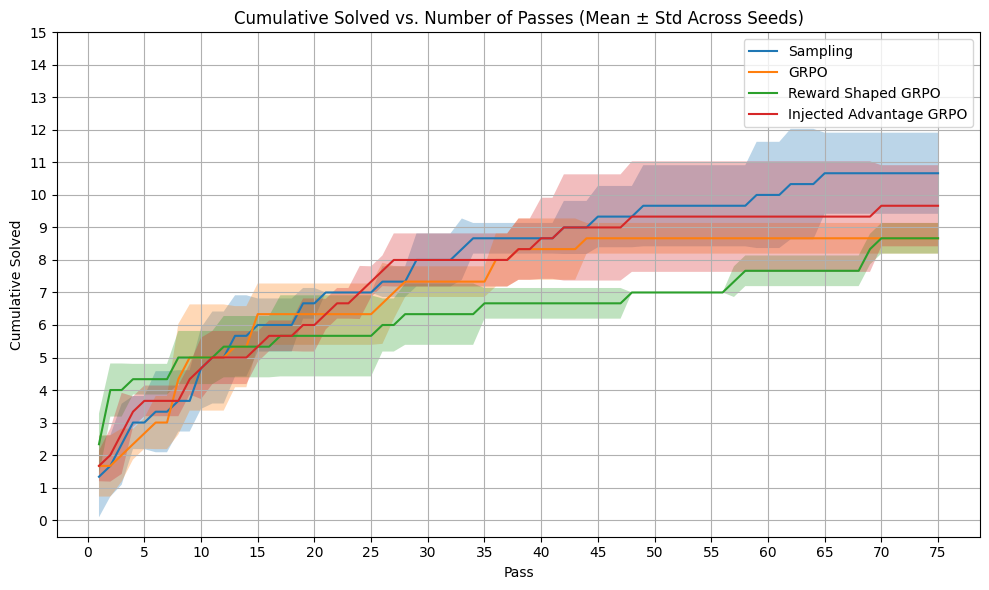

In [2]:
# load the solve rate for each method (use the cumulative solved)


method_dirs = {
    "Sampling": ['../results/training-sample-1-False/epoch_stats.jsonl', '../results/training-sample-2-False/epoch_stats.jsonl', '../results/training-sample-3-False/epoch_stats.jsonl'], 
    "GRPO": ['../results/training-grpo-1-False/epoch_stats.jsonl', '../results/training-grpo-2-False/epoch_stats.jsonl', '../results/training-grpo-3-False/epoch_stats.jsonl'],
    "Reward Shaped GRPO": ['../results/training-grpo-1-True/epoch_stats.jsonl', '../results/training-grpo-2-True/epoch_stats.jsonl', '../results/training-grpo-3-True/epoch_stats.jsonl'],
    "Injected Advantage GRPO": ['../results/training-sparsegrpo-1-False/epoch_stats.jsonl', '../results/training-sparsegrpo-2-False/epoch_stats.jsonl', '../results/training-sparsegrpo-3-False/epoch_stats.jsonl'],
}


plt.figure(figsize=(10, 6))

for label, file_list in method_dirs.items():
    seeds_data = []

    for file in file_list:
        with open(file, "r") as f:
            data = [json.loads(line) for line in f]
            seeds_data.append([entry["n_cumulative_solved"] for entry in data])

    seeds_data = np.array(seeds_data)
    mean = seeds_data.mean(axis=0)
    std = seeds_data.std(axis=0)
    epochs = [entry["epoch"] + 1 for entry in data]  # from last file loaded

    plt.plot(epochs, mean, label=label)
    plt.fill_between(epochs, mean - std, mean + std, alpha=0.3)

plt.title("Cumulative Solved vs. Number of Passes (Mean ± Std Across Seeds)")
plt.xlabel("Pass")
plt.ylabel("Cumulative Solved")
plt.legend()
plt.xticks(np.arange(0, 76, 5))  # From 1 to 75, every 5 steps
plt.yticks(np.arange(0, 16))    

plt.grid(True)
plt.tight_layout()
plt.show()

### Solved At This Epoch

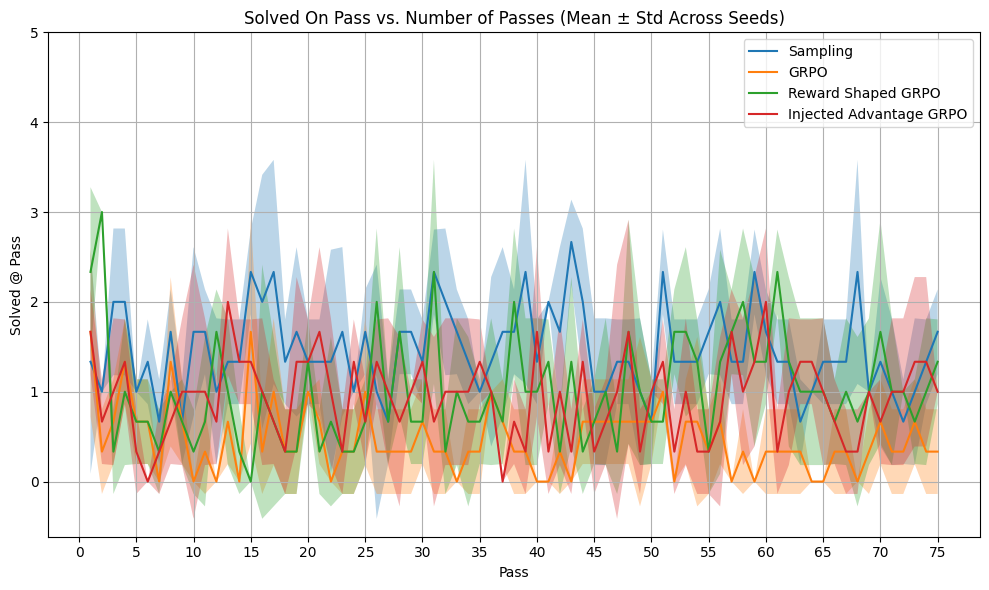

In [3]:
# load the solve rate for each method (use the cumulative solved)


method_dirs = {
    "Sampling": ['../results/training-sample-1-False/epoch_stats.jsonl', '../results/training-sample-2-False/epoch_stats.jsonl', '../results/training-sample-3-False/epoch_stats.jsonl'], 
    "GRPO": ['../results/training-grpo-1-False/epoch_stats.jsonl', '../results/training-grpo-2-False/epoch_stats.jsonl', '../results/training-grpo-3-False/epoch_stats.jsonl'],
    "Reward Shaped GRPO": ['../results/training-grpo-1-True/epoch_stats.jsonl', '../results/training-grpo-2-True/epoch_stats.jsonl', '../results/training-grpo-3-True/epoch_stats.jsonl'],
    "Injected Advantage GRPO": ['../results/training-sparsegrpo-1-False/epoch_stats.jsonl', '../results/training-sparsegrpo-2-False/epoch_stats.jsonl', '../results/training-sparsegrpo-3-False/epoch_stats.jsonl'],
}


plt.figure(figsize=(10, 6))

for label, file_list in method_dirs.items():
    seeds_data = []

    for file in file_list:
        with open(file, "r") as f:
            data = [json.loads(line) for line in f]
            seeds_data.append([entry["n_solved_this_epoch"] for entry in data])

    seeds_data = np.array(seeds_data)
    mean = seeds_data.mean(axis=0)
    std = seeds_data.std(axis=0)
    epochs = [entry["epoch"] + 1 for entry in data]  # from last file loaded

    plt.plot(epochs, mean, label=label)
    plt.fill_between(epochs, mean - std, mean + std, alpha=0.3)

plt.title("Solved On Pass vs. Number of Passes (Mean ± Std Across Seeds)")
plt.xlabel("Pass")
plt.ylabel("Solved @ Pass")
plt.legend()
plt.xticks(np.arange(0, 76, 5))  # From 1 to 75, every 5 steps
plt.yticks(np.arange(0, 6))    

plt.grid(True)
plt.tight_layout()
plt.show()

### Examining Intersection of Tasks

Sampling: 13 tasks solved
GRPO: 12 tasks solved
Reward Shaped GRPO: 12 tasks solved
Injected Advantage GRPO: 14 tasks solved


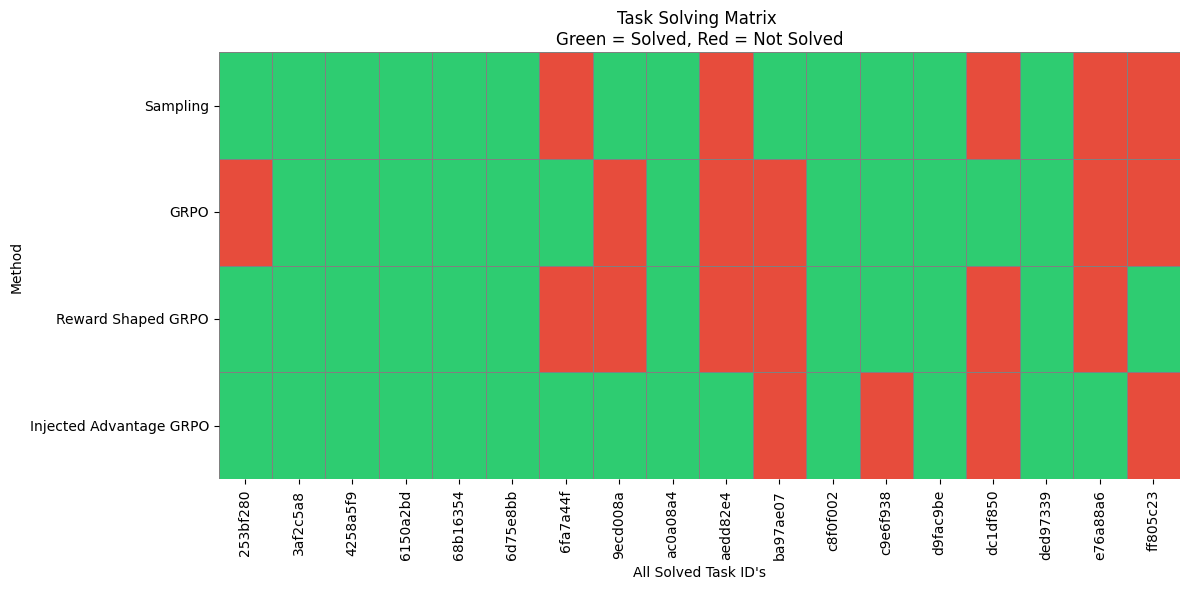

In [22]:
import json
from upsetplot import UpSet, from_memberships
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


method_dirs = {
    "Sampling": ['../results/training-sample-1-False/epoch_stats.jsonl', '../results/training-sample-2-False/epoch_stats.jsonl', '../results/training-sample-3-False/epoch_stats.jsonl'], 
    "GRPO": ['../results/training-grpo-1-False/epoch_stats.jsonl', '../results/training-grpo-2-False/epoch_stats.jsonl', '../results/training-grpo-3-False/epoch_stats.jsonl'],
    "Reward Shaped GRPO": ['../results/training-grpo-1-True/epoch_stats.jsonl', '../results/training-grpo-2-True/epoch_stats.jsonl', '../results/training-grpo-3-True/epoch_stats.jsonl'],
    "Injected Advantage GRPO": ['../results/training-sparsegrpo-1-False/epoch_stats.jsonl', '../results/training-sparsegrpo-2-False/epoch_stats.jsonl', '../results/training-sparsegrpo-3-False/epoch_stats.jsonl'],
}

solved_tasks_by_method = {}

for method, file_list in method_dirs.items():
    all_solved = set()  # will hold unique task names/IDs
    
    for file in file_list:
        with open(file, "r") as f:
            for line in f:
                entry = json.loads(line)
                tasks = entry.get("cumulative_solved", [])
                all_solved.update(tasks)  # union with all tasks seen so far

    solved_tasks_by_method[method] = all_solved
    
    print(f"{method}: {len(all_solved)} tasks solved")


all_tasks = sorted(set.union(*solved_tasks_by_method.values()))
methods = list(solved_tasks_by_method.keys())

df = pd.DataFrame(index=all_tasks, columns=methods)

for method in methods:
    df[method] = df.index.map(lambda task: int(task in solved_tasks_by_method[method]))


# Create a copy to apply highlighting
highlight_df = df.copy()

# Get baseline (Sampling) as reference
baseline = "Sampling"
for method in df.columns:
    if method == baseline:
        continue
    # Mark where the method differs from Sampling
    highlight_df[method] = df[method] - df[baseline]


# Transpose for heatmap
df_T = df.T

# Define a custom colormap: red for 0 (not solved), green for 1 (solved)
cmap_binary = sns.color_palette(["#e74c3c", "#2ecc71"])  # red, green

# Plot the binary task solving matrix
plt.figure(figsize=(12, len(df_T) * 1.5))
sns.heatmap(
    df_T,
    cmap=cmap_binary,
    cbar=False,
    linewidths=0.5,
    linecolor='gray',
    fmt="s",
    annot_kws={"fontsize": 12}
)

plt.title("Task Solving Matrix \nGreen = Solved, Red = Not Solved")
plt.xlabel("All Solved Task ID's")
plt.ylabel("Method")
plt.tight_layout()
plt.show()


Sampling: 13 tasks solved
GRPO: 12 tasks solved
Reward Shaped GRPO: 12 tasks solved
Injected Advantage GRPO: 14 tasks solved


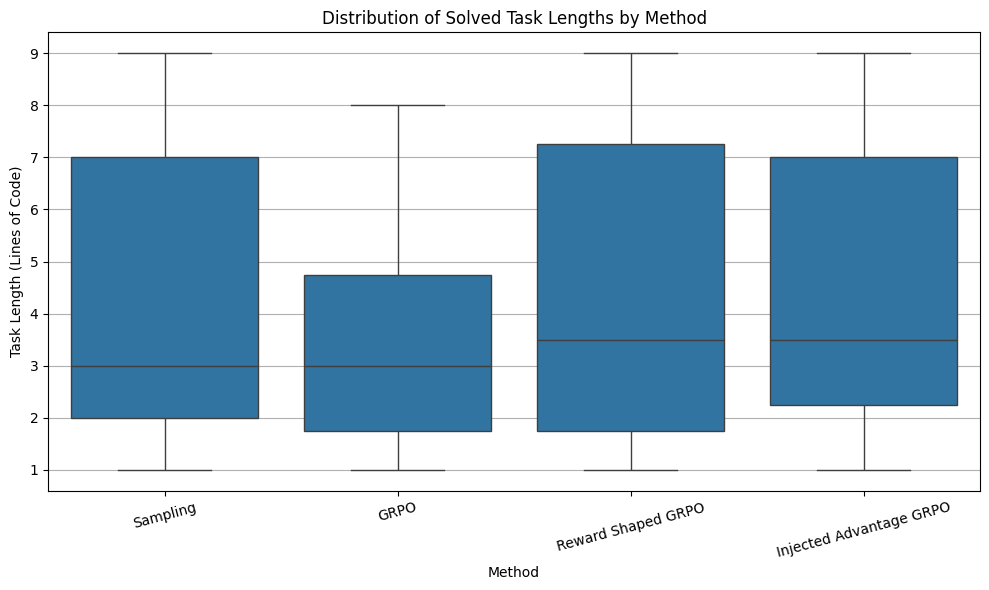

In [28]:
from transformers import T5ForConditionalGeneration, AutoTokenizer
from alphaarc.task import Task
import torch
import matplotlib.pyplot as plt
import numpy as np 
import json
import torch, tqdm, pickle
from pathlib import Path
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from transformers import T5ForConditionalGeneration, AutoTokenizer
from alphaarc.task import Task
import torch
import matplotlib.pyplot as plt
import numpy as np 
import json
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

method_dirs = {
    "Sampling": ['../results/training-sample-1-False/epoch_stats.jsonl', '../results/training-sample-2-False/epoch_stats.jsonl', '../results/training-sample-3-False/epoch_stats.jsonl'], 
    "GRPO": ['../results/training-grpo-1-False/epoch_stats.jsonl', '../results/training-grpo-2-False/epoch_stats.jsonl', '../results/training-grpo-3-False/epoch_stats.jsonl'],
    "Reward Shaped GRPO": ['../results/training-grpo-1-True/epoch_stats.jsonl', '../results/training-grpo-2-True/epoch_stats.jsonl', '../results/training-grpo-3-True/epoch_stats.jsonl'],
    "Injected Advantage GRPO": ['../results/training-sparsegrpo-1-False/epoch_stats.jsonl', '../results/training-sparsegrpo-2-False/epoch_stats.jsonl', '../results/training-sparsegrpo-3-False/epoch_stats.jsonl'],
}

solved_tasks_by_method = {}

for method, file_list in method_dirs.items():
    all_solved = set()  # will hold unique task names/IDs
    
    for file in file_list:
        with open(file, "r") as f:
            for line in f:
                entry = json.loads(line)
                tasks = entry.get("cumulative_solved", [])
                all_solved.update(tasks)  # union with all tasks seen so far

    solved_tasks_by_method[method] = all_solved
    
    print(f"{method}: {len(all_solved)} tasks solved")

with open('../data/split_keys.json') as fp:
    json_object = json.load(fp)

validation_tasks = json_object['val']


validation_task = [ Task.from_json(f'../data/training/{task_id}.json') for task_id in validation_tasks]

validation_task_lengths = {}

for t in validation_task:
    validation_task_lengths[t.task_key] = len(t.program_lines.split("\n"))




# Gather lengths of solved tasks by method
lengths_by_method = {}

for method, tasks in solved_tasks_by_method.items():
    lengths = [validation_task_lengths[t] for t in tasks if t in validation_task_lengths]
    lengths_by_method[method] = lengths

# Convert to DataFrame for plotting
length_df = pd.DataFrame([(method, length) for method, lengths in lengths_by_method.items() for length in lengths],
                         columns=["Method", "Task Length"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=length_df, x="Method", y="Task Length")
plt.title("Distribution of Solved Task Lengths by Method")
plt.ylabel("Task Length (Lines of Code)")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Final thing

['6150a2bd', 'c8f0f002', '68b16354', 'c9e6f938', '6fa7a44f', 'ac0a08a4', '4258a5f9', '9ecd008a', '25ff71a9', '3af2c5a8', '67e8384a', '56ff96f3', 'dc1df850', 'ae4f1146', 'aabf363d', 'aedd82e4', '445eab21', '41e4d17e', 'f5b8619d', '00d62c1b', '3906de3d', '8d5021e8', '0ca9ddb6', 'd0f5fe59', 'ba97ae07', 'd9fac9be', 'ded97339', 'f8ff0b80', 'dbc1a6ce', '496994bd', 'fcb5c309', 'ff805c23', '5c0a986e', '7f4411dc', '6d75e8bb', 'e76a88a6', '8f2ea7aa', '137eaa0f', '6e82a1ae', 'a5f85a15', '4be741c5', '681b3aeb', '3ac3eb23', '253bf280', '3428a4f5', 'a9f96cdd', '1caeab9d', '3de23699', 'bdad9b1f', '88a62173', 'f8b3ba0a', '88a10436', '7e0986d6', 'd4a91cb9', '913fb3ed', '3631a71a', '95990924', '93b581b8', '9edfc990', 'a65b410d', 'ef135b50', '6e19193c', 'cbded52d', 'ae3edfdc', '4612dd53', 'e48d4e1a', '846bdb03', '2204b7a8', 'e5062a87', '539a4f51', '91413438', 'e8dc4411', 'e40b9e2f', 'd6ad076f', 'b190f7f5', '6cdd2623', 'f9012d9b', 'e21d9049', 'eb5a1d5d', '0a938d79', '82819916', 'a78176bb', '952a094c', '98

Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


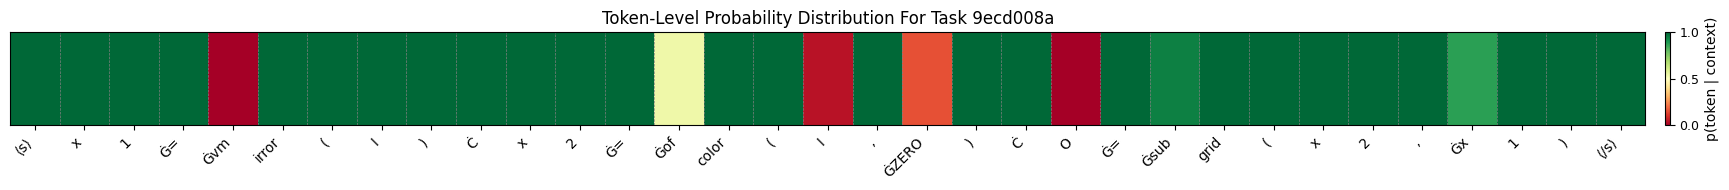

Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


=== Task 9ecd008a Program ===
x1 = vmirror(I)
x2 = ofcolor(I, ZERO)
O = subgrid(x2, x1)


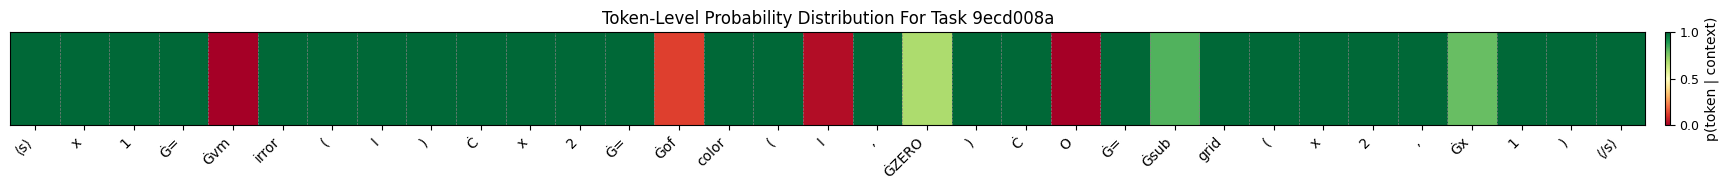

Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


=== Task 9ecd008a Program ===
x1 = vmirror(I)
x2 = ofcolor(I, ZERO)
O = subgrid(x2, x1)


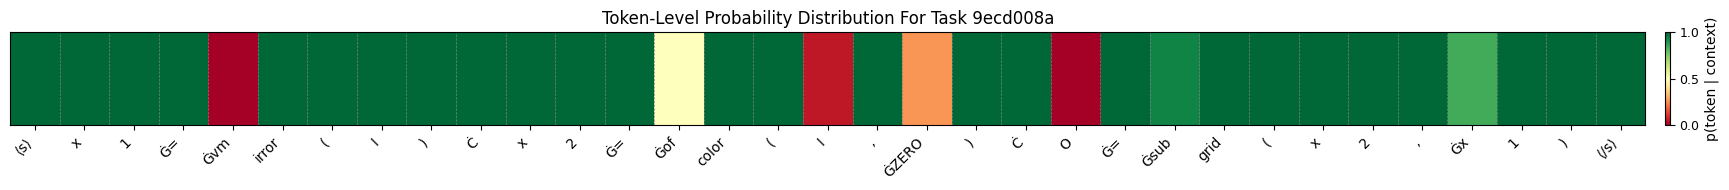

Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


=== Task 9ecd008a Program ===
x1 = vmirror(I)
x2 = ofcolor(I, ZERO)
O = subgrid(x2, x1)


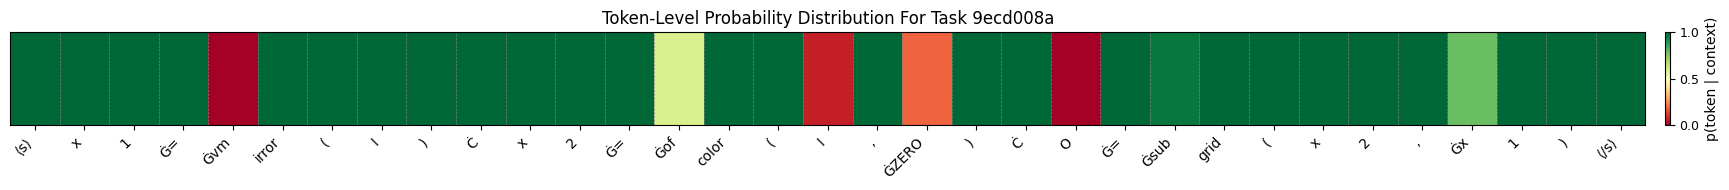

In [34]:

from alphaarc.policy.tokenize import tokenize_task

def encode_task(task, tokenizer, model, input_state_max=256, n_examples=10, max_length=256): 
    tokenized_task = np.array(tokenize_task(task, tokenizer, n_examples, input_state_max, max_length)['input_ids'])
    return tokenized_task


def output_program_lines(task):
    print(f"=== Task {task.task_key} Program ===")

    print(task.program_lines)


def compute_logits(task, model, ): 
    tok      = AutoTokenizer.from_pretrained('Salesforce/codet5p-220m')
    target_text = task.program_lines
    model.eval()

    # teacher-forcing forward pass
    input_   = torch.tensor(encode_task(task, tok, model)).unsqueeze(0)

    ids      = tok(target_text, return_tensors="pt").input_ids

    with torch.no_grad():
        logits = model(input_, labels =ids).logits        # [1, seq_len, vocab]
    
    log_p     = torch.log_softmax(logits, -1)

    token_logp = log_p.gather(2, ids.unsqueeze(-1)).squeeze(-1)  
    p_token    = token_logp.exp().squeeze().tolist()            
    tokens     = tok.convert_ids_to_tokens(ids[0])

    return tokens, p_token


 
def output_correct_token_probs(task_id, tokens, p_token): 
    fig, ax = plt.subplots(figsize=(len(tokens) * 0.6, 2))
    im = ax.imshow(np.array([p_token]), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

    display_tokens = [t.replace("<s>", "⟨s⟩").replace("</s>", "⟨/s⟩") for t in tokens]

    ax.set_yticks([])
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(display_tokens, rotation=45, ha="right", fontsize=10)
    
    ax.set_xticks(np.arange(-.5, len(tokens), 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='--', linewidth=0.5)
    ax.tick_params(axis='x', which='minor', bottom=False)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label("p(token | context)", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    plt.title(f"Token-Level Probability Distribution For Task {task_id}")
    plt.tight_layout()
    plt.savefig('../figures/sequence-level-probs.png')
    plt.show()

def generate_task_level_analysis(task_id, model_path='../finetune/2025-05-27_17-42-37/checkpoint-1100'): 
    task = Task.from_json(f'../data/training/{task_id}.json')
    model = T5ForConditionalGeneration.from_pretrained(model_path)
    output_program_lines(task)
    tokens, p_token = compute_logits(task, model)
    output_correct_token_probs(task.task_key, tokens, p_token)


print(validation_tasks)
# change here the task and model you wish to use.
task = validation_tasks[7]
generate_task_level_analysis(task, model_path='../results/training-sample-1-False/model_epoch_60')
generate_task_level_analysis(task, model_path='../results/training-grpo-1-False/model_epoch_60')
generate_task_level_analysis(task, model_path='../results/training-grpo-1-True/model_epoch_60')
generate_task_level_analysis(task, model_path='../results/training-sparsegrpo-1-False/model_epoch_60')



Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


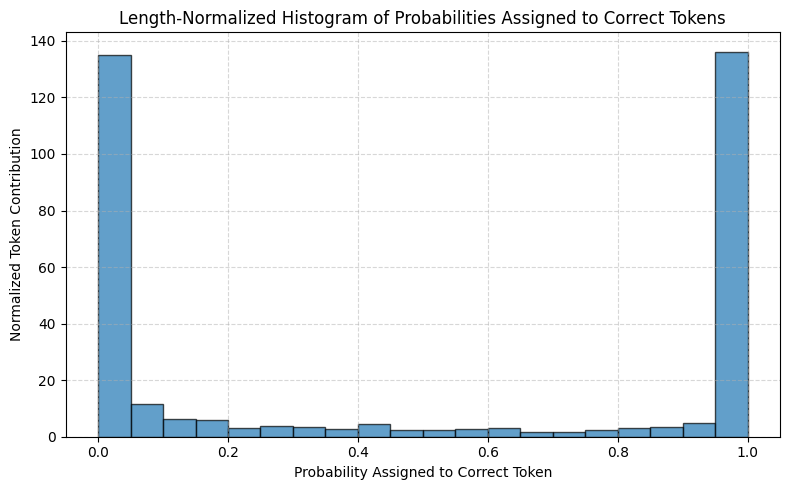

Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


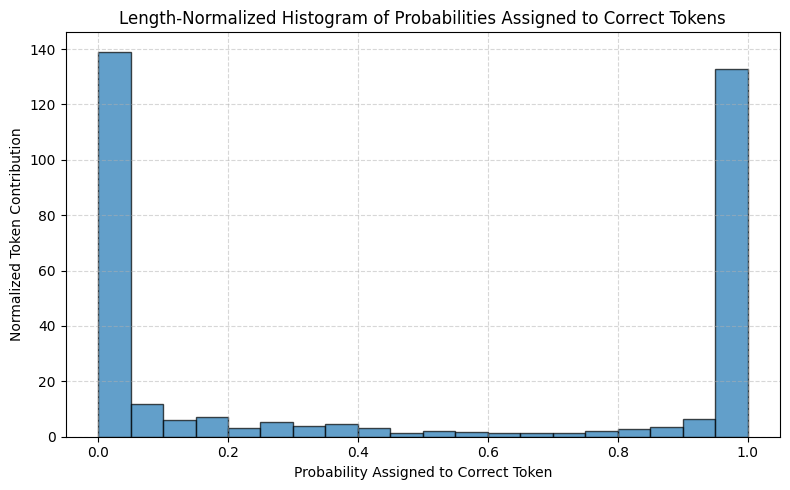

Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


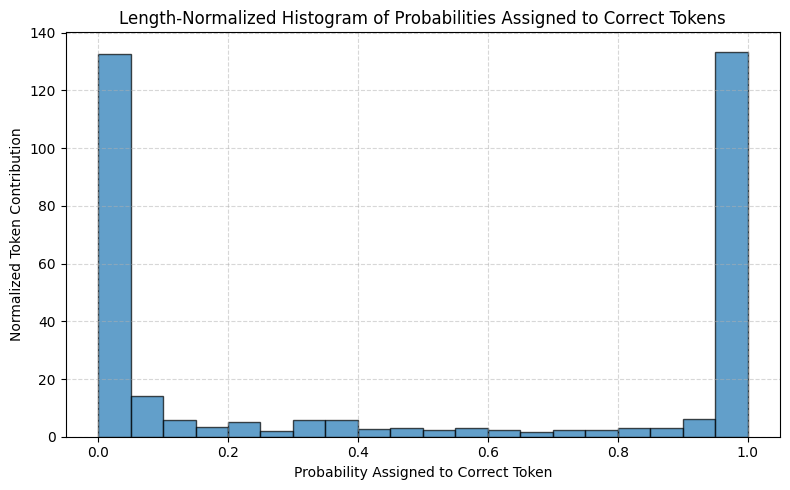

Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


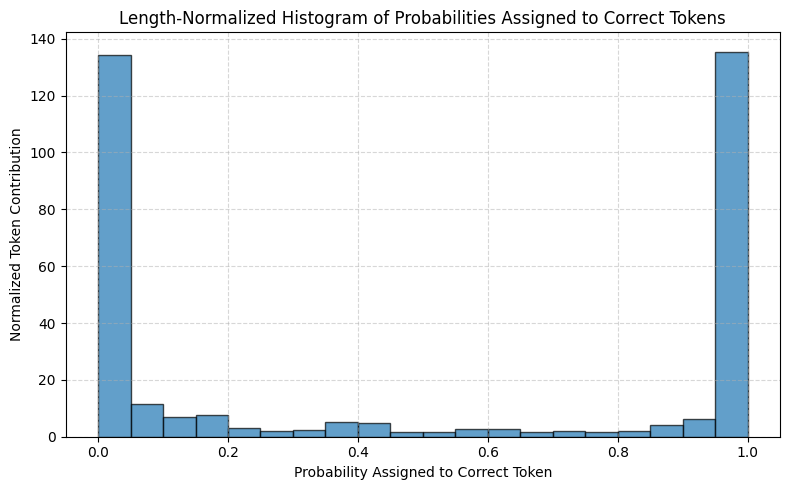

In [35]:
from collections import Counter

def token_stats(logits, ids):
    log_p = torch.log_softmax(logits, -1)           # [1, L, V]
    probs = log_p.exp()

    entropy = -(probs * log_p).sum(-1).squeeze(0)   # [L]  (nats)

    # top-1 correctness
    top1_ids = logits.argmax(-1)                    # [1, L]
    is_correct = (top1_ids == ids).float().squeeze(0)

    p_true = probs.gather(2, ids.unsqueeze(-1)).squeeze(0).squeeze(-1)

    return entropy.cpu(), is_correct.cpu(), p_true.cpu()


def compute_logits(task, model, tokenizer):
    target_text = task.program_lines
    model.eval()

    input_ids = torch.tensor(
        encode_task(task, tokenizer, model)
    ).unsqueeze(0).to(model.device)

    ids = tokenizer(target_text, return_tensors="pt").input_ids.to(model.device)

    with torch.no_grad():
        logits = model(input_ids, labels=ids).logits

    entropy, is_correct, p_true = token_stats(logits, ids)

    
    log_p       = torch.log_softmax(logits, -1)
    token_logp  = log_p.gather(2, ids.unsqueeze(-1)).squeeze(-1)
    p_token     = token_logp.exp().squeeze().tolist()
    tokens      = tokenizer.convert_ids_to_tokens(ids[0])
    return tokens, p_token, entropy



def compute_correct_token_probs(tasks, model_path, tokenizer_path='Salesforce/codet5p-220m'): 
    model = T5ForConditionalGeneration.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    
    token_probs = []
    all_tokens = []

    for task_id in tasks:
        task = Task.from_json(f'../data/training/{task_id}.json')
        tokens, p_token, _ = compute_logits(task, model, tokenizer)

        token_probs.extend(p_token)
        all_tokens.extend(tokens)
    
    return token_probs, all_tokens


def plot_correct_token_probs(result, filename):
    from collections import Counter

    correct_token_probs, tokens = result
    
    # Count how frequently each token appears
    token_freq = Counter(tokens)
    weights = [1 / token_freq[token] for token in tokens]

    # Plot with weights
    plt.figure(figsize=(8, 5))
    plt.hist(correct_token_probs, bins=20, range=(0, 1), weights=weights, edgecolor='black', alpha=0.7)
    plt.title('Length-Normalized Histogram of Probabilities Assigned to Correct Tokens')
    plt.xlabel('Probability Assigned to Correct Token')
    plt.ylabel('Normalized Token Contribution')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(filename)

    plt.show()


result = compute_correct_token_probs(validation_tasks,
                                                '../results/training-sample-1-False/model_epoch_60')
plot_correct_token_probs(result, filename='../figures/main-model-histogram.png')
result = compute_correct_token_probs(validation_tasks,
                                                '../results/training-grpo-1-False/model_epoch_60')

plot_correct_token_probs(result, filename='../figures/main-model-histogram.png')
result = compute_correct_token_probs(validation_tasks,
                                                '../results/training-grpo-1-True/model_epoch_60')

plot_correct_token_probs(result, filename='../figures/main-model-histogram.png')

result = compute_correct_token_probs(validation_tasks,
                                                '../results/training-sparsegrpo-1-False/model_epoch_60')
plot_correct_token_probs(result, filename='../figures/main-model-histogram.png')


Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


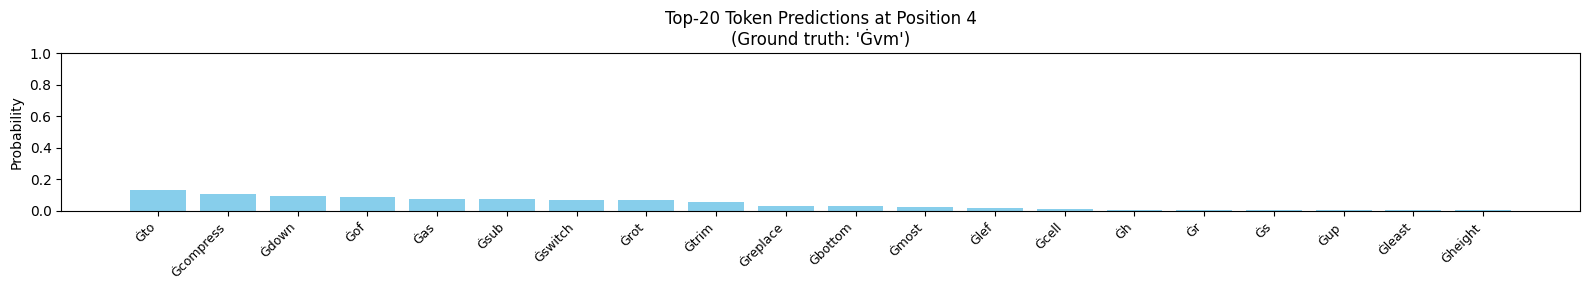

Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


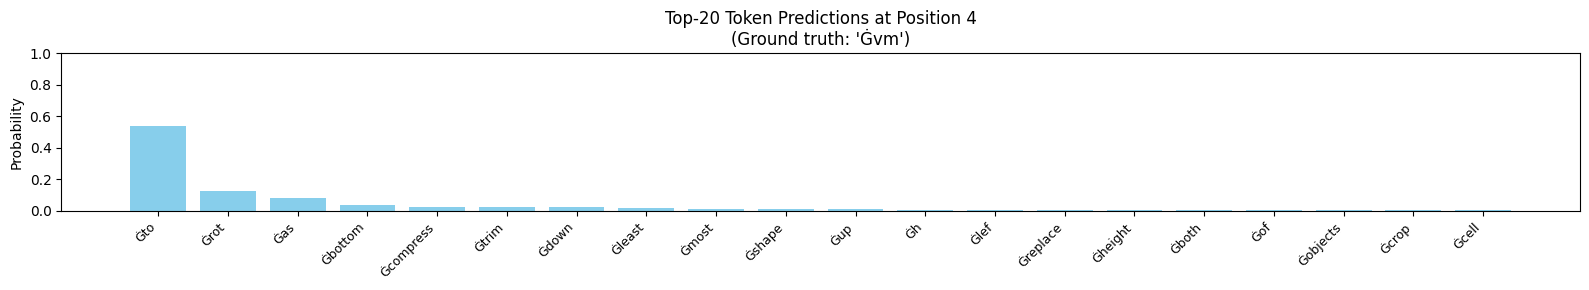

Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


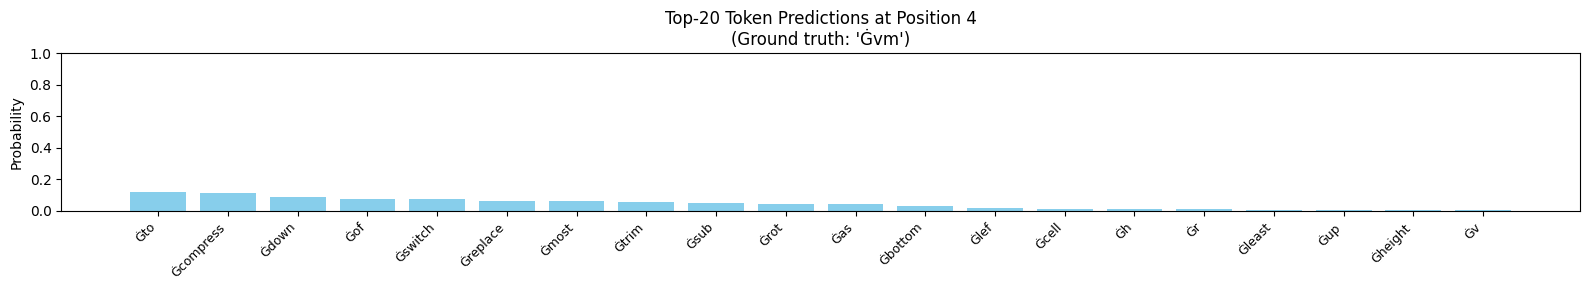

Token indices sequence length is longer than the specified maximum sequence length for this model (1742 > 512). Running this sequence through the model will result in indexing errors


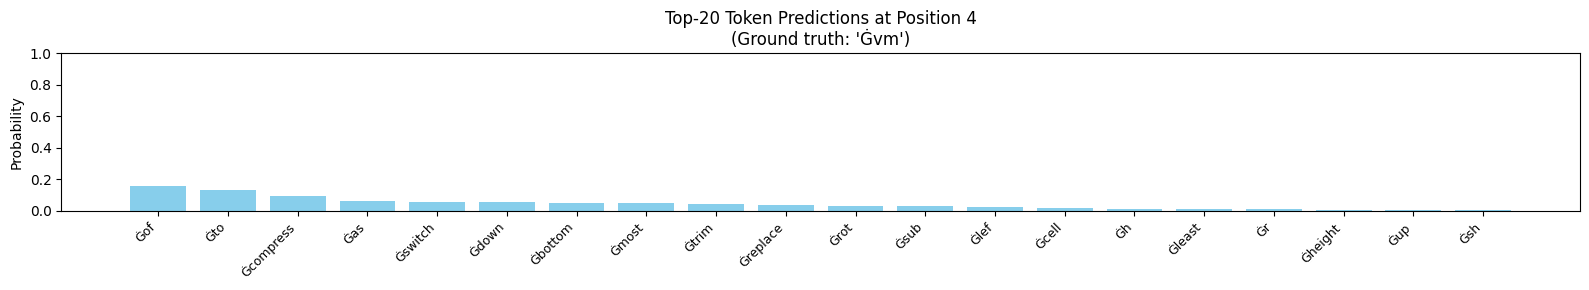

In [36]:
import matplotlib.pyplot as plt
import numpy as np



def compute_logits(task, model, tokenizer):
    target_text = task.program_lines
    model.eval()

    input_ids = torch.tensor(
        encode_task(task, tokenizer, model)
    ).unsqueeze(0).to(model.device)

    ids = tokenizer(target_text, return_tensors="pt").input_ids.to(model.device)

    with torch.no_grad():
        logits = model(input_ids, labels=ids).logits

    entropy, is_correct, p_true = token_stats(logits, ids)

    
    log_p       = torch.log_softmax(logits, -1)
    token_logp  = log_p.gather(2, ids.unsqueeze(-1)).squeeze(-1)
    p_token     = token_logp.exp().squeeze().tolist()
    tokens      = tokenizer.convert_ids_to_tokens(ids[0])

    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()  # Shape: (T, V)
    return tokens, probs



def compute_probs_for_task(task_id, model_path, tokenizer_path='Salesforce/codet5p-220m'):
    model = T5ForConditionalGeneration.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    

    task = Task.from_json(f'../data/training/{task_id}.json')
    tokens, probs = compute_logits(task, model, tokenizer)


    return tokens, probs

def output_token_distributions_topk(task_id, tokens, p_token, tokenizer, top_k=10):
    """
    tokens: list of ground-truth tokens (len = sequence length)
    p_token: array of shape (sequence length, vocab size)
    tokenizer: a tokenizer object with `convert_ids_to_tokens()` method
    top_k: number of top tokens to show per timestep
    """
    import matplotlib.pyplot as plt
    import numpy as np

    seq_len, vocab_size = p_token.shape
    fig, axs = plt.subplots(1, seq_len, figsize=(seq_len * 1.5, 3), sharey=True)

    if seq_len == 1:
        axs = [axs]

    display_tokens = [t.replace("<s>", "⟨s⟩").replace("</s>", "⟨/s⟩") for t in tokens]

    for i, (ax, dist, label) in enumerate(zip(axs, p_token, display_tokens)):
        topk_idx = np.argsort(dist)[-top_k:][::-1]
        topk_probs = dist[topk_idx]
        topk_labels = tokenizer.convert_ids_to_tokens(topk_idx)

        ax.bar(range(top_k), topk_probs, color='skyblue')
        ax.set_xticks(range(top_k))
        ax.set_xticklabels(topk_labels, rotation=45, ha='right', fontsize=7)
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1])
        ax.set_title(label, fontsize=9)

    fig.suptitle(f"Top-{top_k} Token Distributions for Task {task_id}", fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.75)
    plt.savefig('../figures/topk-token-distributions.png')
    plt.show()

import matplotlib.pyplot as plt
import numpy as np

def output_token_distribution_at_position(task_id, tokens, probs, tokenizer, position=0, top_k=10):
    """
    Visualizes top-k token probabilities at a single position in the sequence.

    Parameters:
        task_id: identifier for the task (used in title/saving)
        tokens: list of ground-truth tokens (sequence)
        probs: np.ndarray of shape (seq_len, vocab_size)
        tokenizer: Hugging Face tokenizer (used to decode token ids)
        position: int — index of the token position to visualize
        top_k: int — number of top tokens to show
    """
    if isinstance(probs, list):
        probs = np.array(probs)

    if probs.ndim != 2:
        raise ValueError("Expected `probs` to have shape (sequence_length, vocab_size)")

    if position >= len(tokens):
        raise IndexError(f"Position {position} out of range for sequence of length {len(tokens)}")

    token_probs = probs[position]  # shape: (vocab_size,)
    topk_idx = np.argsort(token_probs)[-top_k:][::-1]
    topk_probs = token_probs[topk_idx]
    topk_tokens = tokenizer.convert_ids_to_tokens(topk_idx)

    plt.figure(figsize=(top_k * 0.8, 3))
    bars = plt.bar(range(top_k), topk_probs, color='skyblue')
    plt.xticks(range(top_k), topk_tokens, rotation=45, ha='right', fontsize=9)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title(f"Top-{top_k} Token Predictions at Position {position}\n(Ground truth: '{tokens[position]}')")

    # Optionally highlight the true token in red if it's in top-k
    true_token = tokens[position]
    try:
        true_token_id = tokenizer.convert_tokens_to_ids(true_token)
        if true_token_id in topk_idx:
            idx_in_topk = list(topk_idx).index(true_token_id)
            bars[idx_in_topk].set_color('green')
    except:
        pass  # token not found or unknown token

    plt.tight_layout()
    plt.savefig(f'../figures/topk-token-distribution-pos{position}.png')
    plt.show()




task_id= '9ecd008a'
tokens, p_token = compute_probs_for_task(task_id,  model_path= '../results/training-sample-1-False/model_epoch_60')
output_token_distribution_at_position(task_id, tokens, p_token, AutoTokenizer.from_pretrained('Salesforce/codet5p-220m'), position= 4, top_k=20)

tokens, p_token = compute_probs_for_task(task_id,  model_path= '../results/training-grpo-1-False/model_epoch_60')
output_token_distribution_at_position(task_id, tokens, p_token, AutoTokenizer.from_pretrained('Salesforce/codet5p-220m'), position= 4, top_k=20)

tokens, p_token = compute_probs_for_task(task_id,  model_path= '../results/training-grpo-1-True/model_epoch_60')
output_token_distribution_at_position(task_id, tokens, p_token, AutoTokenizer.from_pretrained('Salesforce/codet5p-220m'), position= 4, top_k=20)

tokens, p_token = compute_probs_for_task(task_id,  model_path= '../results/training-sparsegrpo-1-False/model_epoch_60')
output_token_distribution_at_position(task_id, tokens, p_token, AutoTokenizer.from_pretrained('Salesforce/codet5p-220m'), position= 4, top_k=20)

## Evaluation Set

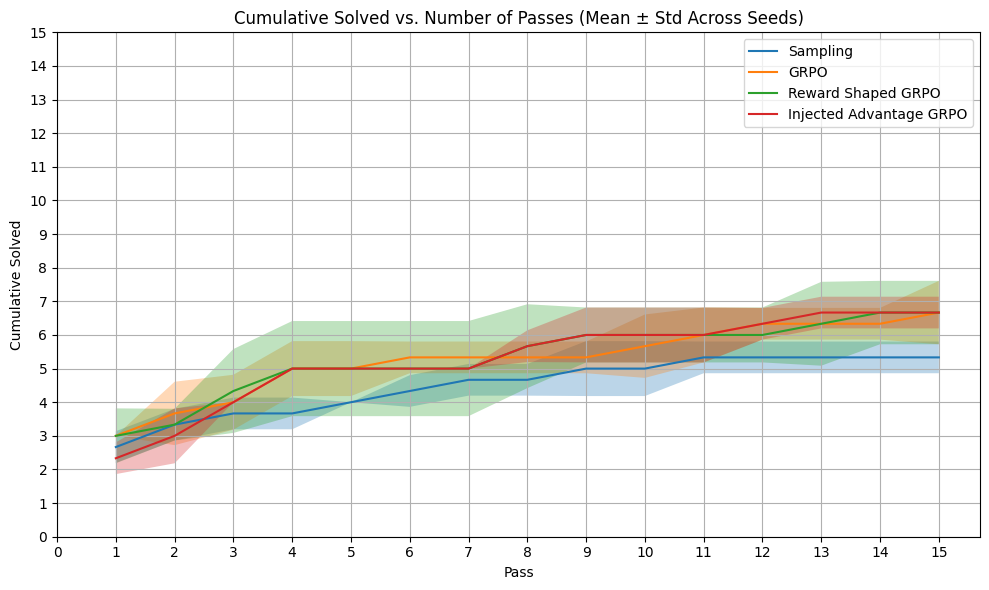

In [42]:

method_dirs = {
    "Sampling": ['../results/evaluation-sample-1-False-15/epoch_stats.jsonl', '../results/evaluation-sample-2-False-15/epoch_stats.jsonl', '../results/evaluation-sample-3-False-15/epoch_stats.jsonl'], 
    "GRPO": ['../results/evaluation-grpo-1-False/epoch_stats.jsonl', '../results/evaluation-grpo-2-False/epoch_stats.jsonl', '../results/evaluation-grpo-3-False/epoch_stats.jsonl'],
    "Reward Shaped GRPO": ['../results/evaluation-grpo-1-True/epoch_stats.jsonl', '../results/evaluation-grpo-2-True/epoch_stats.jsonl', '../results/evaluation-grpo-3-True/epoch_stats.jsonl'],
    "Injected Advantage GRPO": ['../results/evaluation-sparsegrpo-1-False/epoch_stats.jsonl', '../results/evaluation-sparsegrpo-2-False/epoch_stats.jsonl', '../results/evaluation-sparsegrpo-3-False/epoch_stats.jsonl'],
}


plt.figure(figsize=(10, 6))

for label, file_list in method_dirs.items():
    seeds_data = []

    for file in file_list:
        with open(file, "r") as f:
            data = [json.loads(line) for line in f]
            seeds_data.append([entry["n_cumulative_solved"] for entry in data])

    seeds_data = np.array(seeds_data)
    mean = seeds_data.mean(axis=0)
    std = seeds_data.std(axis=0)
    epochs = [entry["epoch"] + 1 for entry in data]  # from last file loaded

    plt.plot(epochs, mean, label=label)
    plt.fill_between(epochs, mean - std, mean + std, alpha=0.3)

plt.title("Cumulative Solved vs. Number of Passes (Mean ± Std Across Seeds)")
plt.xlabel("Pass")
plt.ylabel("Cumulative Solved")
plt.legend()
plt.xticks(np.arange(0, 16, 1))  # From 1 to 75, every 5 steps
plt.yticks(np.arange(0, 16))    

plt.grid(True)
plt.tight_layout()
plt.show()


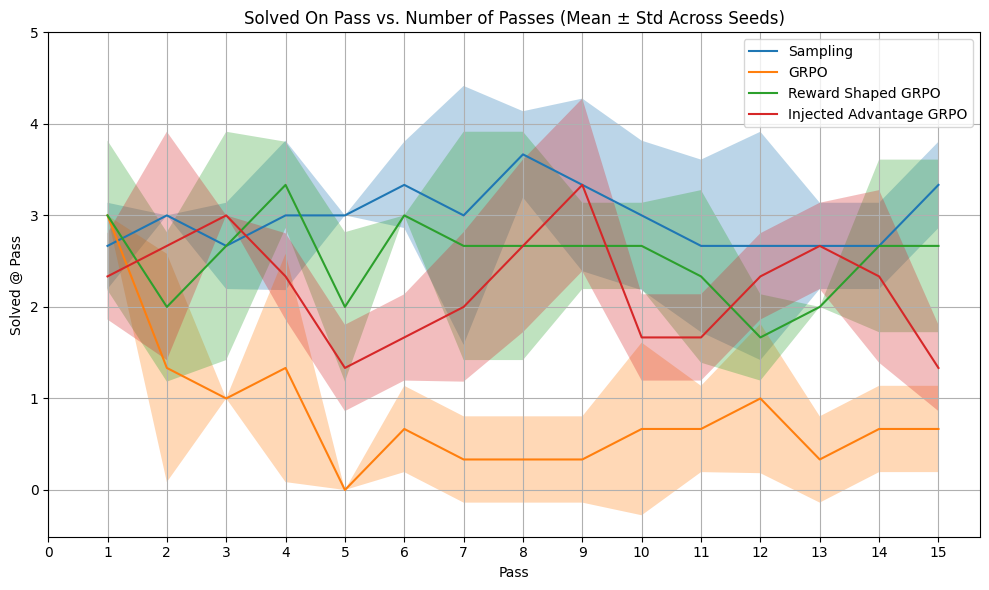

In [45]:

plt.figure(figsize=(10, 6))

for label, file_list in method_dirs.items():
    seeds_data = []

    for file in file_list:
        with open(file, "r") as f:
            data = [json.loads(line) for line in f]
            seeds_data.append([entry["n_solved_this_epoch"] for entry in data])

    seeds_data = np.array(seeds_data)
    mean = seeds_data.mean(axis=0)
    std = seeds_data.std(axis=0)
    epochs = [entry["epoch"] + 1 for entry in data]  # from last file loaded

    plt.plot(epochs, mean, label=label)
    plt.fill_between(epochs, mean - std, mean + std, alpha=0.3)

plt.title("Solved On Pass vs. Number of Passes (Mean ± Std Across Seeds)")
plt.xlabel("Pass")
plt.ylabel("Solved @ Pass")
plt.legend()
plt.xticks(np.arange(0, 16))  # From 1 to 75, every 5 steps
plt.yticks(np.arange(0, 6))    

plt.grid(True)
plt.tight_layout()
plt.show()

Sampling: 8 tasks solved
GRPO: 8 tasks solved
Reward Shaped GRPO: 10 tasks solved
Injected Advantage GRPO: 9 tasks solved


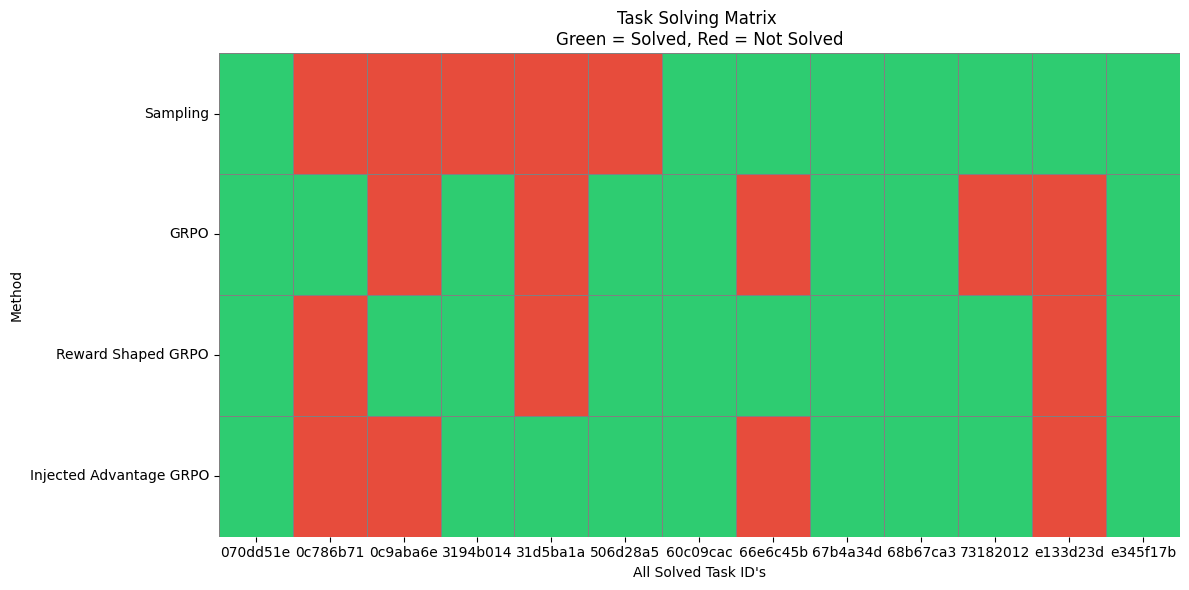

In [46]:

solved_tasks_by_method = {}

for method, file_list in method_dirs.items():
    all_solved = set()  # will hold unique task names/IDs
    
    for file in file_list:
        with open(file, "r") as f:
            for line in f:
                entry = json.loads(line)
                tasks = entry.get("cumulative_solved", [])
                all_solved.update(tasks)  # union with all tasks seen so far

    solved_tasks_by_method[method] = all_solved
    
    print(f"{method}: {len(all_solved)} tasks solved")


all_tasks = sorted(set.union(*solved_tasks_by_method.values()))
methods = list(solved_tasks_by_method.keys())

df = pd.DataFrame(index=all_tasks, columns=methods)

for method in methods:
    df[method] = df.index.map(lambda task: int(task in solved_tasks_by_method[method]))


# Create a copy to apply highlighting
highlight_df = df.copy()

# Get baseline (Sampling) as reference
baseline = "Sampling"
for method in df.columns:
    if method == baseline:
        continue
    # Mark where the method differs from Sampling
    highlight_df[method] = df[method] - df[baseline]


# Transpose for heatmap
df_T = df.T

# Define a custom colormap: red for 0 (not solved), green for 1 (solved)
cmap_binary = sns.color_palette(["#e74c3c", "#2ecc71"])  # red, green

# Plot the binary task solving matrix
plt.figure(figsize=(12, len(df_T) * 1.5))
sns.heatmap(
    df_T,
    cmap=cmap_binary,
    cbar=False,
    linewidths=0.5,
    linecolor='gray',
    fmt="s",
    annot_kws={"fontsize": 12}
)

plt.title("Task Solving Matrix \nGreen = Solved, Red = Not Solved")
plt.xlabel("All Solved Task ID's")
plt.ylabel("Method")
plt.tight_layout()
plt.show()
